# Employee Retention Prediction Capstone Project
**Boston Institute of Analytics**

This notebook follows the project guidelines:
- Comprehensive EDA
- Data preprocessing
- Feature engineering
- Multiple model comparison
- Imbalanced data handling
- Performance evaluation
- Final test-set prediction export

**Dataset files used**
- `aug_train.csv`
- `aug_test.csv`

**Problem Statement**  
Build a machine learning model to predict whether a data scientist is likely to look for a job change (`target = 1`).

## 1. Import libraries

In [7]:
!pip install xgboost lightgbm imbalanced-learn

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the datasets

In [9]:
train_path = "aug_train.csv"
test_path = "aug_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()

Train shape: (19158, 14)
Test shape : (2129, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 3. Basic structure and data understanding

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [12]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,NaN,NaN,NaN,16875.358179,9616.292592,1.0,8554.25,16982.5,25169.75,33380.0
city,19158,123,city_103,4355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_development_index,19158.0,NaN,NaN,NaN,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
gender,14650,3,Male,13221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relevent_experience,19158,2,Has relevent experience,13792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enrolled_university,18772,3,no_enrollment,13817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,18698,5,Graduate,11598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_discipline,16345,6,STEM,14492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experience,19093,22,>20,3286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,13220,8,50-99,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("Missing values in training data:")
display(train_df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(train_df["target"].value_counts())
display((train_df["target"].value_counts(normalize=True) * 100).round(2))

Missing values in training data:


company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
enrollee_id                  0
city                         0
relevent_experience          0
city_development_index       0
training_hours               0
target                       0
dtype: int64


Target distribution:


target
0.0    14381
1.0     4777
Name: count, dtype: int64

target
0.0    75.07
1.0    24.93
Name: proportion, dtype: float64

## 4. Advanced Exploratory Data Analysis (EDA)

We will explore:
- missing values
- target imbalance
- numeric feature distributions
- categorical feature relationships with target
- correlation among numeric features

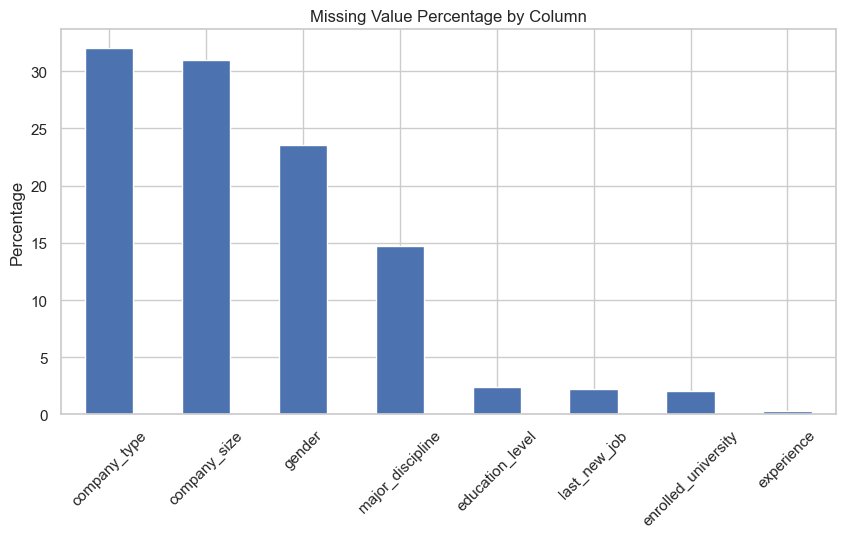

In [14]:
# Missing value percentage
missing_pct = (train_df.isnull().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind="bar")
plt.title("Missing Value Percentage by Column")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

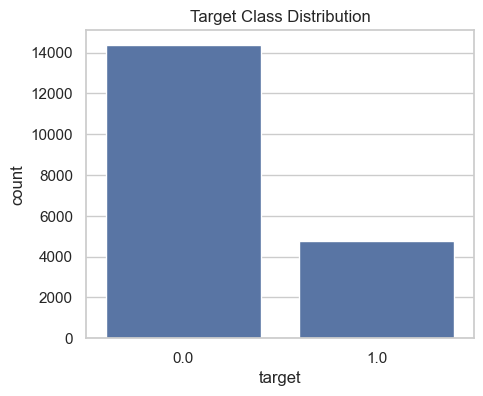

Imbalance Ratio:
target
0.0    0.7507
1.0    0.2493
Name: proportion, dtype: float64


In [15]:
plt.figure(figsize=(5, 4))
sns.countplot(data=train_df, x="target")
plt.title("Target Class Distribution")
plt.show()

print("Imbalance Ratio:")
print(train_df["target"].value_counts(normalize=True).round(4))

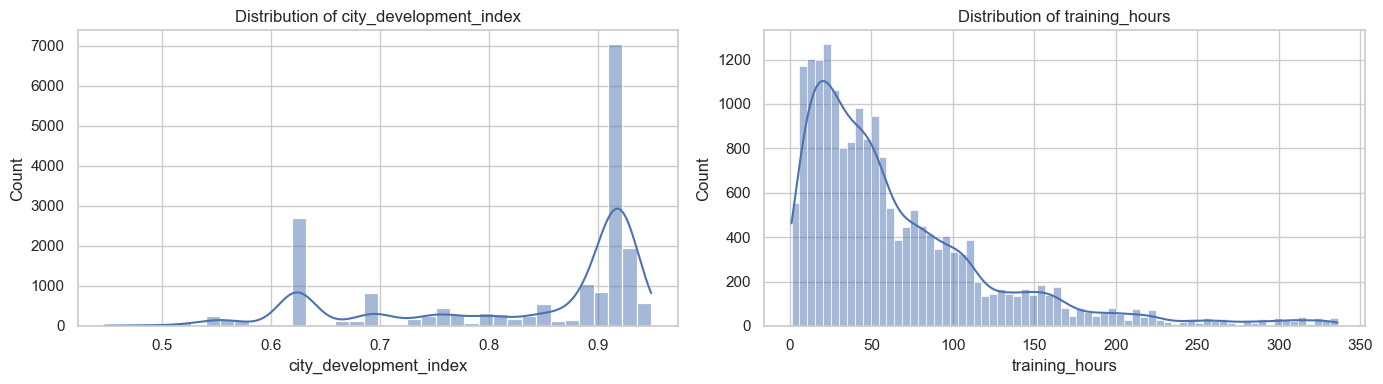

In [16]:
numeric_cols_raw = ["city_development_index", "training_hours"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(numeric_cols_raw):
    sns.histplot(train_df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

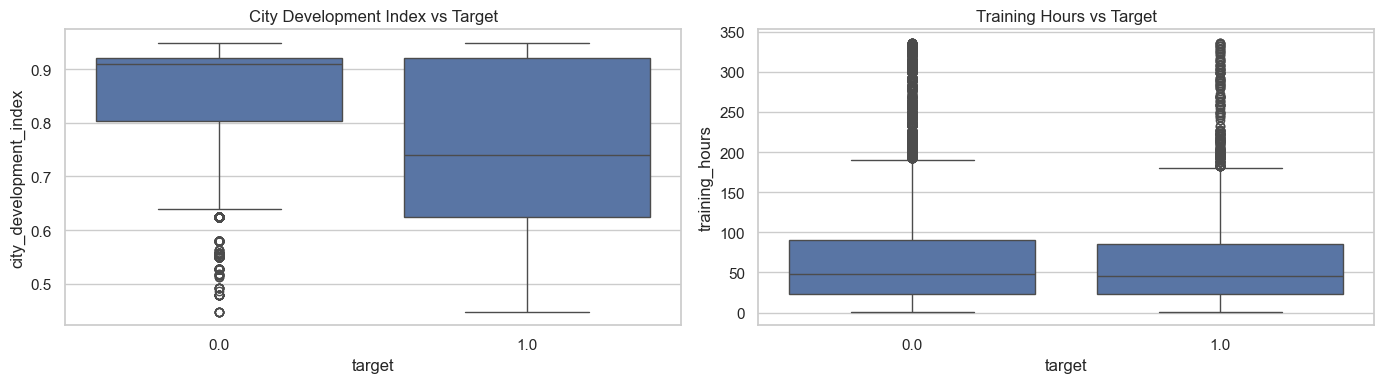

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=train_df, x="target", y="city_development_index", ax=axes[0])
axes[0].set_title("City Development Index vs Target")

sns.boxplot(data=train_df, x="target", y="training_hours", ax=axes[1])
axes[1].set_title("Training Hours vs Target")
plt.tight_layout()
plt.show()

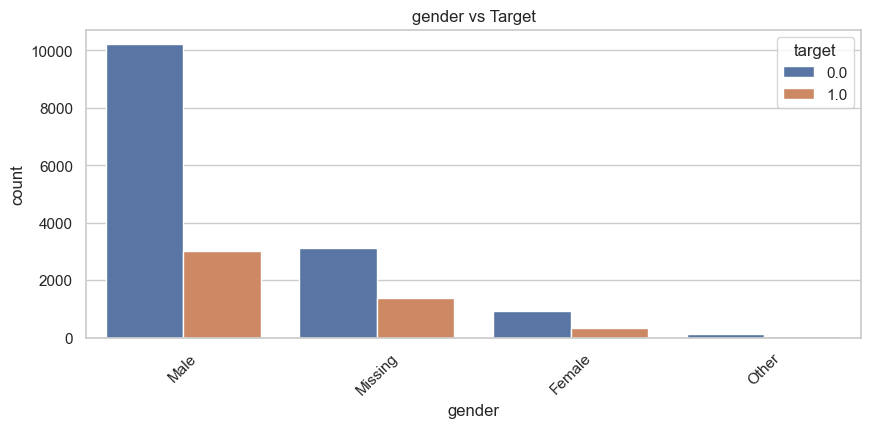

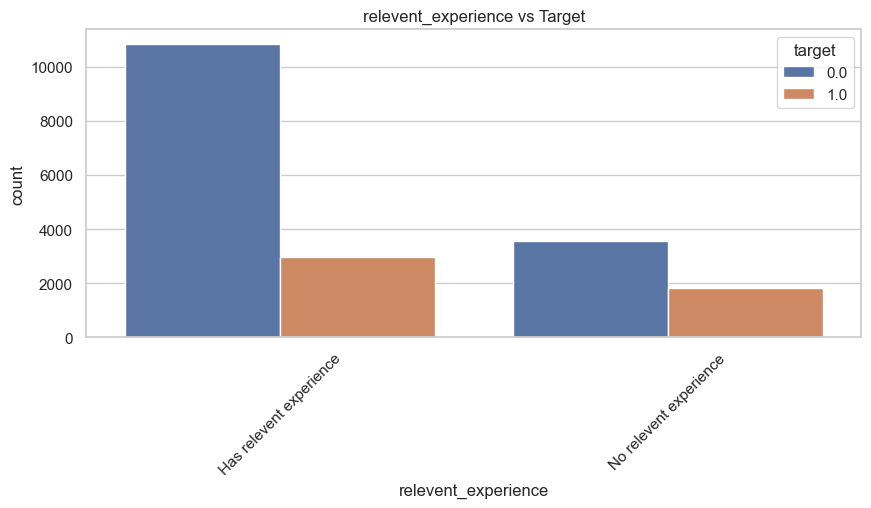

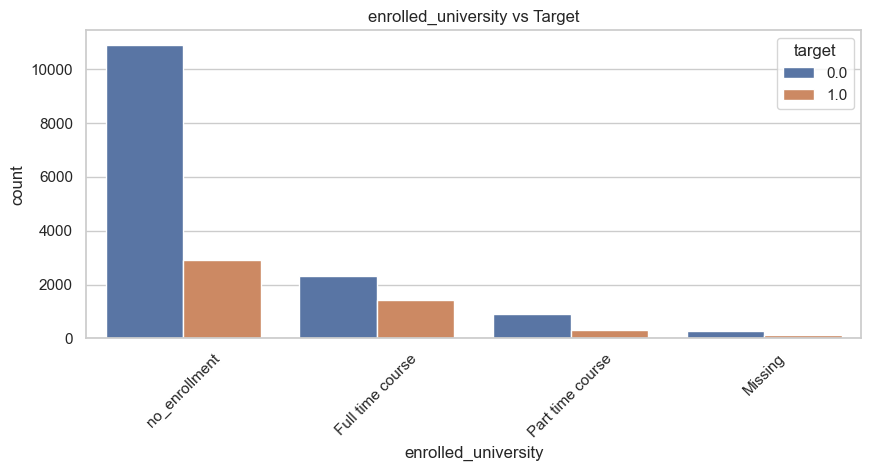

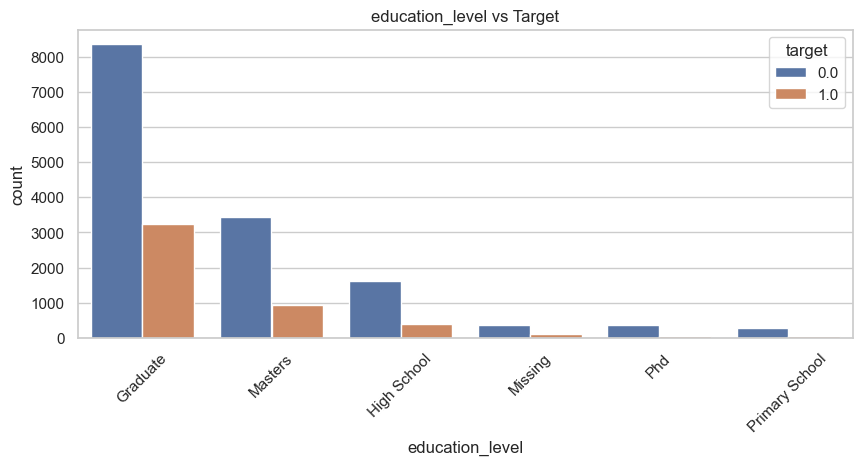

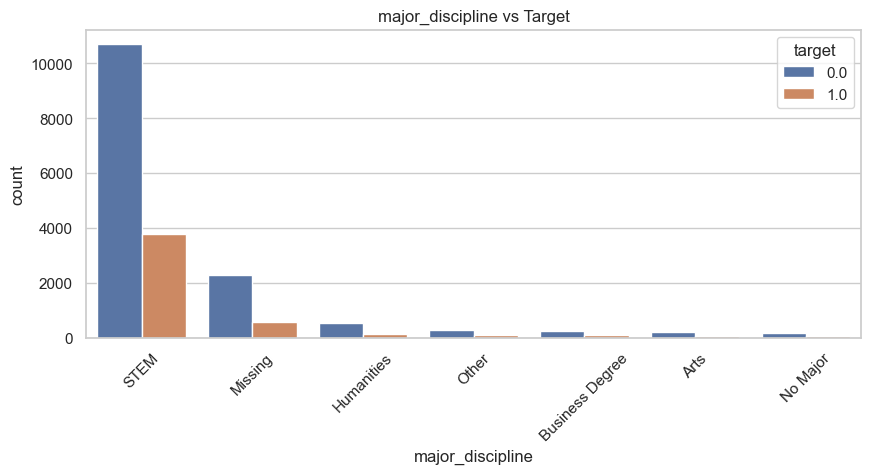

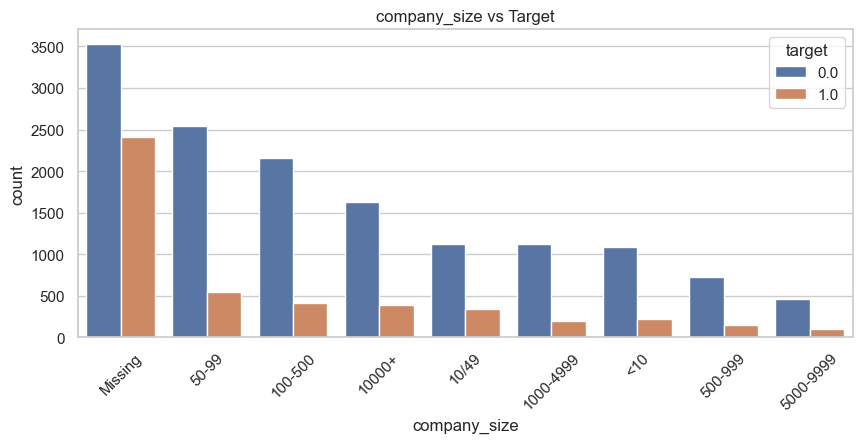

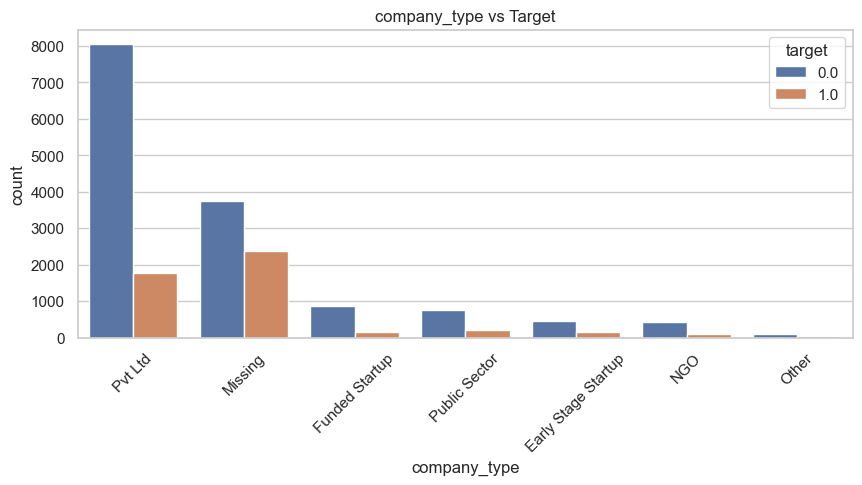

In [18]:
top_categorical_cols = [
    "gender", "relevent_experience", "enrolled_university",
    "education_level", "major_discipline", "company_size",
    "company_type"
]

for col in top_categorical_cols:
    plt.figure(figsize=(10, 4))
    order = train_df[col].fillna("Missing").value_counts().index
    sns.countplot(data=train_df.fillna({col: "Missing"}), x=col, hue="target", order=order)
    plt.title(f"{col} vs Target")
    plt.xticks(rotation=45)
    plt.show()

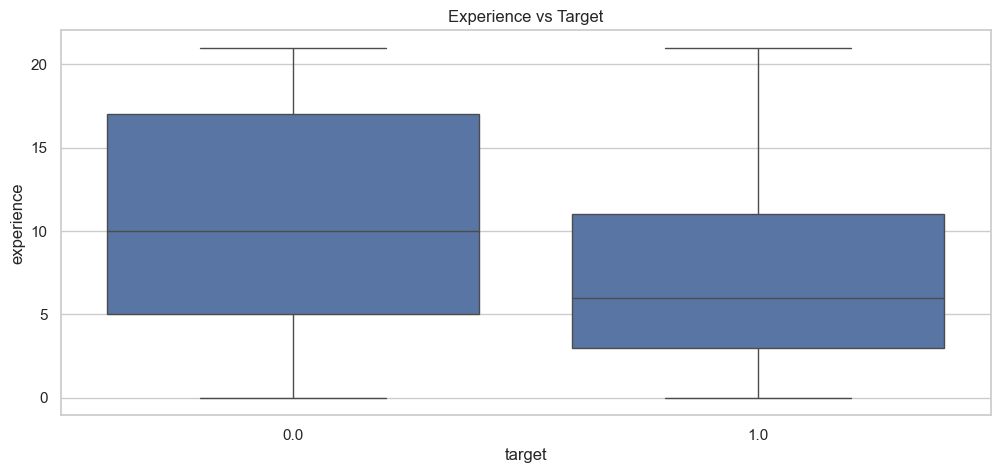

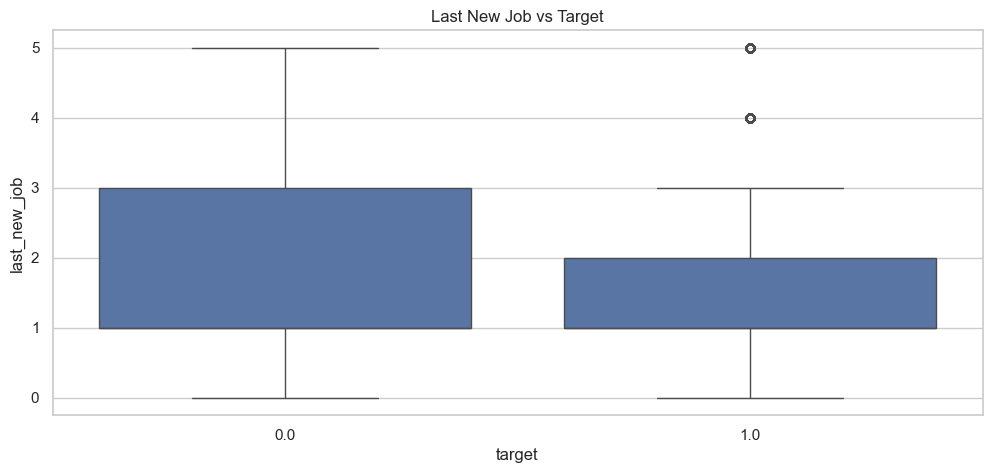

In [19]:
# Clean a few numeric-like categorical columns only for EDA view
eda_df = train_df.copy()
eda_df["experience"] = eda_df["experience"].replace({">20": "21", "<1": "0"})
eda_df["last_new_job"] = eda_df["last_new_job"].replace({">4": "5", "never": "0"})
eda_df["experience"] = pd.to_numeric(eda_df["experience"], errors="coerce")
eda_df["last_new_job"] = pd.to_numeric(eda_df["last_new_job"], errors="coerce")

plt.figure(figsize=(12, 5))
sns.boxplot(data=eda_df, x="target", y="experience")
plt.title("Experience vs Target")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=eda_df, x="target", y="last_new_job")
plt.title("Last New Job vs Target")
plt.show()

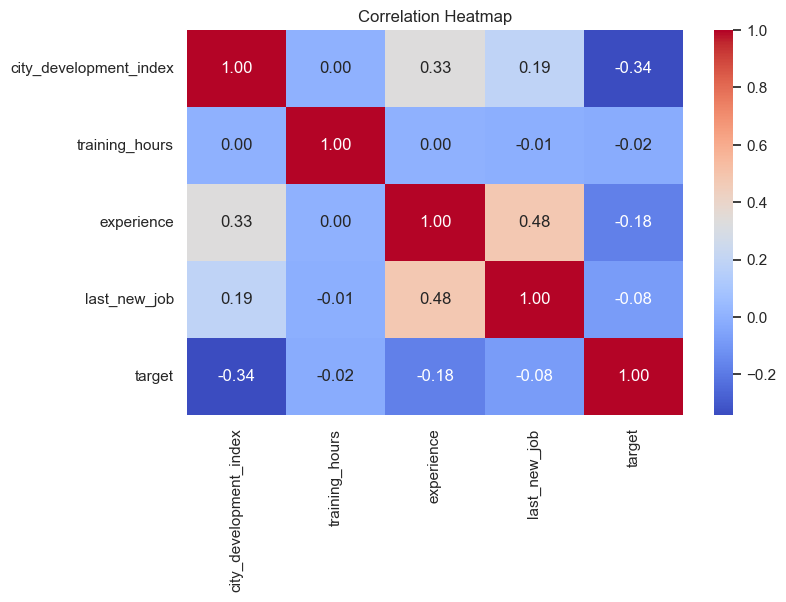

In [20]:
corr_df = eda_df[["city_development_index", "training_hours", "experience", "last_new_job", "target"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Key EDA observations

1. The target is imbalanced: around 75% class 0 and 25% class 1.
2. Many categorical columns contain missing values, especially `company_size`, `company_type`, and `major_discipline`.
3. `experience` and `last_new_job` contain special values like `>20`, `<1`, `>4`, and `never`, so they need cleaning.
4. `city_development_index`, training history, experience, and company-related fields appear useful for prediction.

## 5. Data cleaning and feature engineering

In [21]:
def clean_and_engineer_features(df):
    df = df.copy()

    # Convert special string values to numeric-friendly values
    df["experience"] = df["experience"].replace({">20": "21", "<1": "0"})
    df["last_new_job"] = df["last_new_job"].replace({">4": "5", "never": "0"})

    df["experience"] = pd.to_numeric(df["experience"], errors="coerce")
    df["last_new_job"] = pd.to_numeric(df["last_new_job"], errors="coerce")

    # Additional simple engineered features
    df["is_male"] = df["gender"].map({"Male": 1, "Female": 0, "Other": 2})
    df["has_relevant_experience"] = df["relevent_experience"].map({
        "Has relevent experience": 1,
        "No relevent experience": 0
    })

    return df

train_model_df = clean_and_engineer_features(train_df)
test_model_df = clean_and_engineer_features(test_df)

train_model_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,is_male,has_relevant_experience
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,NaN,NaN,1.0,36,1.0,1.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,5.0,47,0.0,1.0,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,0.0,83,0.0,NaN,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,0.0,52,1.0,NaN,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,50-99,Funded Startup,4.0,8,0.0,1.0,1


## 6. Split features and target

In [22]:
X = train_model_df.drop(columns=["target"])
y = train_model_df["target"].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(4))

X_train shape: (15326, 15)
X_valid shape: (3832, 15)
y_train distribution:
target
0    0.7506
1    0.2494
Name: proportion, dtype: float64


## 7. Preprocessing pipeline

In [23]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

Numeric columns: ['enrollee_id', 'city_development_index', 'experience', 'last_new_job', 'training_hours', 'is_male', 'has_relevant_experience']
Categorical columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']


## 8. Train multiple models

We compare:
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

For imbalance:
- `class_weight='balanced'` for Logistic Regression, Random Forest, and LightGBM
- `scale_pos_weight` for XGBoost

In [24]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale positive weight for XGBoost:", round(imbalance_ratio, 2))

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        class_weight="balanced",
        n_jobs=2
    ),
    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=2,
        scale_pos_weight=imbalance_ratio
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=42,
        class_weight="balanced",
        verbose=-1,
        n_jobs=2
    )
}

Scale positive weight for XGBoost: 3.01


In [25]:
results = []

fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_valid)
    y_proba = pipeline.predict_proba(X_valid)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1 Score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_proba)
    })

    fitted_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.755219,0.505834,0.771728,0.611111,0.807617
1,LightGBM,0.755480,0.506173,0.772775,0.611687,0.804176
2,Random Forest,0.777140,0.575486,0.403141,0.474138,0.795169
3,Logistic Regression,0.744781,0.492107,0.750785,0.594527,0.795111


### Expected result from this dataset
On this dataset, XGBoost and LightGBM usually perform best by ROC-AUC, while Random Forest may show higher accuracy but lower recall for the positive class.

## 9. Best model evaluation

In [26]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print("Best model selected:", best_model_name)

y_pred_best = best_pipeline.predict(X_valid)
y_proba_best = best_pipeline.predict_proba(X_valid)[:, 1]

print("Classification Report:")
print(classification_report(y_valid, y_pred_best))

Best model selected: XGBoost
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      2877
           1       0.51      0.77      0.61       955

    accuracy                           0.76      3832
   macro avg       0.71      0.76      0.72      3832
weighted avg       0.81      0.76      0.77      3832



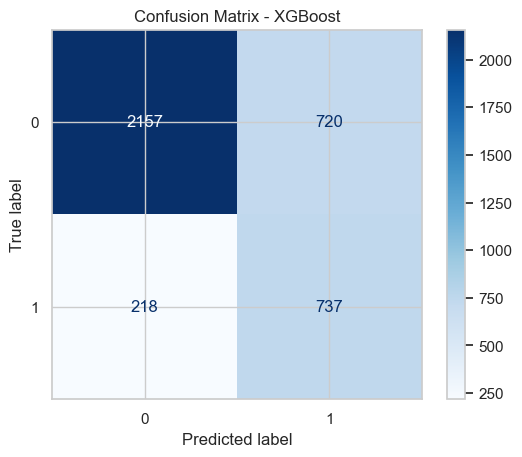

In [27]:
cm = confusion_matrix(y_valid, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

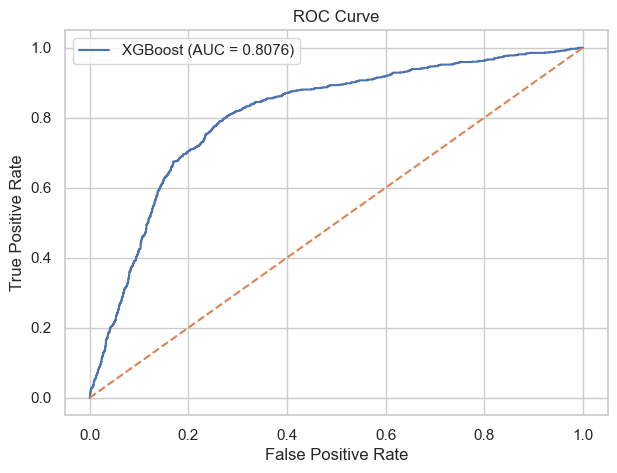

In [28]:
fpr, tpr, thresholds = roc_curve(y_valid, y_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_valid, y_proba_best):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Feature importance

This shows the most important features influencing job change predicition**.

,feature,importance
70,cat__city_city_21,0.091621
152,cat__company_size_50-99,0.063439
1,num__city_development_index,0.047807
133,cat__relevent_experience_No relevent experience,0.037331
12,cat__city_city_103,0.021872
18,cat__city_city_11,0.020649
20,cat__city_city_114,0.019623
55,cat__city_city_160,0.017224
54,cat__city_city_16,0.016411
137,cat__education_level_Graduate,0.016278


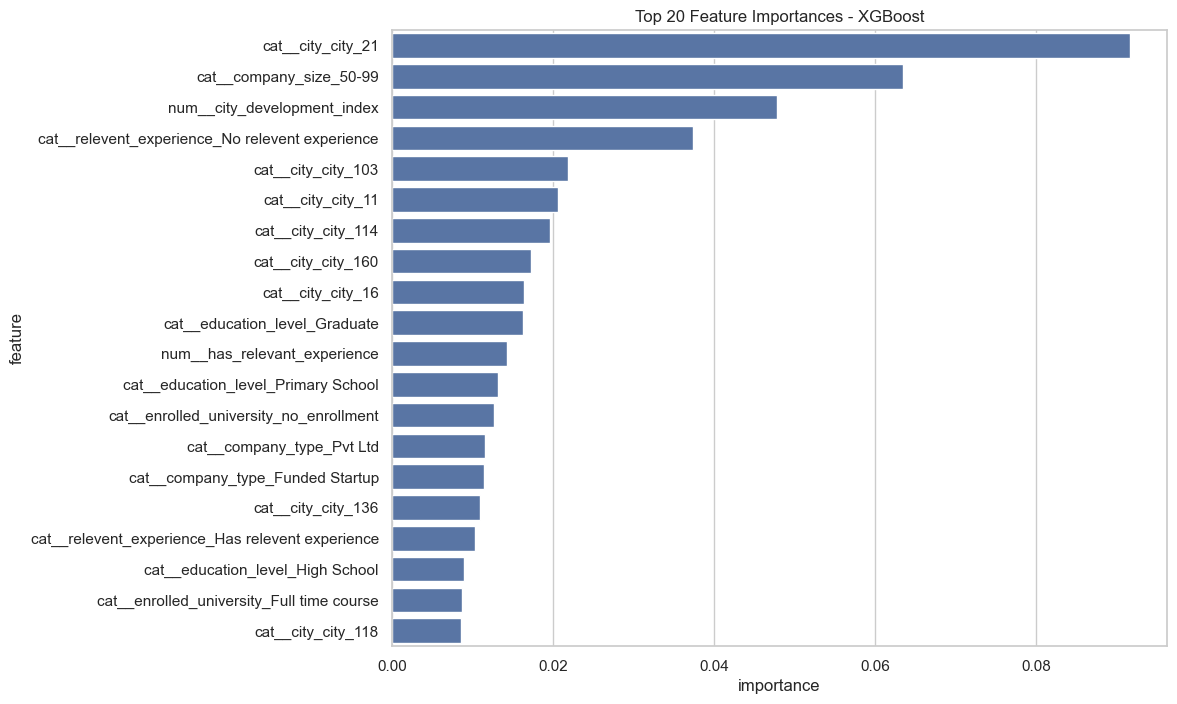

In [29]:
if best_model_name in ["XGBoost", "Random Forest", "LightGBM"]:
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
    model = best_pipeline.named_steps["model"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values(by="importance", ascending=False).head(20)

    display(feature_importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance_df, x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.show()
else:
    print("Feature importance plot skipped because the best model does not provide direct importances.")

## 11. SMOTE / Imbalanced data handling demonstration

To handle class imbalance,we applied the SMOTE technique.

In [30]:
# Separate preprocessing for SMOTENC
smote_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

smote_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

smote_preprocessor = ColumnTransformer(transformers=[
    ("num", smote_numeric_transformer, numeric_cols),
    ("cat", smote_categorical_transformer, categorical_cols)
], sparse_threshold=0)

categorical_feature_indices = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))

smote_pipeline = ImbPipeline(steps=[
    ("preprocessor", smote_preprocessor),
    ("smote", SMOTENC(categorical_features=categorical_feature_indices, random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])

smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_valid)
smote_proba = smote_pipeline.predict_proba(X_valid)[:, 1]

smote_result = {
    "Model": "SMOTENC + Logistic Regression",
    "Accuracy": accuracy_score(y_valid, smote_pred),
    "Precision": precision_score(y_valid, smote_pred),
    "Recall": recall_score(y_valid, smote_pred),
    "F1 Score": f1_score(y_valid, smote_pred),
    "ROC-AUC": roc_auc_score(y_valid, smote_proba)
}

pd.DataFrame([smote_result])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SMOTENC + Logistic Regression,0.697286,0.428671,0.645026,0.51505,0.735128


## 12. Train final model on full training data

 Train the selected best model using the **entire training dataset** and generate predictions for `aug_test.csv`.

In [31]:
final_model_name = best_model_name
final_model = models[final_model_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipeline.fit(X, y)

test_predictions = final_pipeline.predict(test_model_df)
test_probabilities = final_pipeline.predict_proba(test_model_df)[:, 1]

prediction_output = test_df.copy()
prediction_output["predicted_target"] = test_predictions
prediction_output["predicted_probability"] = test_probabilities

prediction_output.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,predicted_target,predicted_probability
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21,0,0.308911
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98,1,0.598158
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15,1,0.742945
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39,0,0.232416
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72,0,0.198247


In [32]:
prediction_output.to_csv("employee_retention_predictions.csv", index=False)
joblib.dump(final_pipeline, "employee_retention_best_model.pkl")

print("Files saved successfully:")
print("- employee_retention_predictions.csv")
print("- employee_retention_best_model.pkl")

Files saved successfully:
- employee_retention_predictions.csv
- employee_retention_best_model.pkl


## 13. Conclusion

•	Performed exploratory data analysis to understand data distribution, missing values, and class imbalance.
•	Cleaned important features such as experience and last_new_job.
•	Built preprocessing pipelines for numerical and categorical data.
•	Compared multiple machine learning models.
•	Evaluated models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
•	Applied SMOTE technique to handle class imbalance.
•	Selected the best-performing model and generated predictions.

### Final conclusion
****“XGBoost / LightGBM performed best for this problem, achieving strong predictive performance and ROC-AUC score. The model can help organizations identify employees likely to change jobs and improve retention strategies.”